# 05 — Исторические метрики по сегментам

## Цель ноутбука

Прежде чем ранжировать сегменты для таргетинга, нам нужно понять, **как каждый сегмент ведёт себя исторически**.

Рекомендательная система будет использовать эти данные как «досье» на каждый сегмент:  
- Когда активен (в какие сезоны)?
- Какой средний чек и длина пребывания?
- Как далеко заранее бронирует?
- Часто ли отменяет?
- Как реагирует на скидки?

## Что мы строим?

1. **Сводная таблица метрик** по каждому `cluster_v4` — общая «карточка сегмента»
2. **Сезонная матрица affinity** — доля активности сегмента по сезонам (уже была в кластеризации, переносим сюда)
3. **Месячный профиль** — детализация по месяцам

## Входные данные
- `ml/data/silver.csv` — сырые бронирования
- `ml/clustering/artifacts_v4/df_guests_with_clusters_v4.parquet` — кластерные метки гостей

## Выходные артефакты
- `artifacts_recommender/segment_history.parquet` — метрики по сегментам
- `artifacts_recommender/segment_monthly.parquet` — профиль по месяцам
- `artifacts_recommender/season_affinity.parquet` — матрица affinity

## 1. Импорты и настройки

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Пути ──────────────────────────────────────────────────────────────────────
ROOT        = Path('..').resolve()
DATA_DIR    = ROOT / 'data'
CLUSTER_DIR = ROOT / 'clustering' / 'artifacts_v4'
OUT_DIR     = Path('artifacts_recommender')
OUT_DIR.mkdir(exist_ok=True)

# ── Параметры ─────────────────────────────────────────────────────────────────
DATA_START = '2022-01-01'
HISTORY_END = None  # вычисляем после загрузки как max(created_dt)

# Названия сегментов для читаемости отчётов
SEGMENT_NAMES = {
    0: 'Summer Family ULTRA',
    1: 'Weekend Getaway',
    2: 'Weekday Adults',
    3: 'Last-minute Winter',
    4: 'Young Spring Groups',
    5: 'Medical Treatment'
}

COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

print('Пути настроены:')
print(f'  Данные:     {DATA_DIR}')
print(f'  Кластеры:   {CLUSTER_DIR}')
print(f'  Выход:      {OUT_DIR.resolve()}')

C:\Users\sp1ts\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Пути настроены:
  Данные:     C:\workspace\my_project\diplom\booking\ml\data
  Кластеры:   C:\workspace\my_project\diplom\booking\ml\clustering\artifacts_v4
  Выход:      C:\workspace\my_project\diplom\booking\ml\recommender\artifacts_recommender


## 2. Загрузка и объединение данных

Нам нужны две таблицы:
1. `silver.csv` — исходные данные бронирований с check_in_dt, длиной пребывания, скидками
2. `df_guests_with_clusters_v4.parquet` — к каждому `guest_id` добавлен `cluster_v4`

Объединяем через `guest_id`, чтобы к каждому бронированию знать сегмент.

In [2]:
# Загружаем бронирования — только нужные колонки
RAW_COLS = [
    'created_dt',
    'grp_norm',
    'guest_id',
    'check_in_dt',
    'check_out_dt',
    'is_valid',
    'tariff',        # нужен для исключения служебных/ФСС тарифов
    'discount',      # размер скидки
    'prev_stays',    # количество предыдущих визитов из CRM
    'places',        # количество мест в бронировании
]

df_header = pd.read_csv(DATA_DIR / 'silver.csv', nrows=0)
usecols = [c for c in RAW_COLS if c in df_header.columns]

df_raw = pd.read_csv(
    DATA_DIR / 'silver.csv',
    usecols=usecols,
    parse_dates=[c for c in ['created_dt', 'check_in_dt', 'check_out_dt'] if c in usecols],
    low_memory=False
)
HISTORY_END = df_raw['created_dt'].max().normalize()

print(f'Загружено строк: {len(df_raw):,}')
print(f'Дата среза выгрузки: {HISTORY_END.date()}')

# Загружаем кластеры
df_clusters = pd.read_parquet(
    CLUSTER_DIR / 'df_guests_with_clusters_v4.parquet'
)
print(f'Гостей с кластерами: {len(df_clusters):,}')
print(f'Колонки кластерного файла: {list(df_clusters.columns)}')

Загружено строк: 565,816
Дата среза выгрузки: 2025-10-30
Гостей с кластерами: 248,547
Колонки кластерного файла: ['guest_id', 'stay_duration', 'lead_time', 'guest_age', 'prev_stays', 'pct_weekend_in', 'price_tier', 'has_children', 'is_treatment', 'pct_summer', 'pct_autumn', 'pct_winter', 'pct_spring', 'age_is_unknown', 'gender', 'tariff_group', 'room_group', 'n_stays', 'cluster_k4', 'cluster_k5', 'cluster_k6', 'cluster_v4']


In [3]:
# Фильтруем бронирования: только валидные и согласованные с forecasting
df = df_raw[df_raw['is_valid'] == 1].copy()
df = df.dropna(subset=['check_in_dt', 'check_out_dt'])
df = df[df['check_out_dt'] > df['check_in_dt']]

# Используем тот же наблюдаемый период, что и forecasting: после COVID и до даты выгрузки.
df = df[df['check_in_dt'] >= DATA_START]
df = df[df['check_in_dt'] <= HISTORY_END]

# Исключаем служебные и нерыночные тарифы, как в forecasting/clustering.
if 'tariff' in df.columns:
    service_mask = df['tariff'].str.contains(
        r'Служебный|СОТРУДНИКИ|Сотрудник|НЕ СЕЛИТЬ', na=False, regex=True
    )
    corp_mask = df['tariff'].str.contains(
        r'ФСС|Согаз|корпор|КОРПОР', na=False, regex=True
    )
    df = df[~service_mask & ~corp_mask]

print(f'После фильтрации: {len(df):,} строк')

# Добавляем cluster_v4 через join по guest_id
# Из кластерного файла берём только guest_id + cluster_v4 + основные признаки
cluster_cols = ['guest_id', 'cluster_v4', 'stay_duration', 'lead_time',
                'price_tier', 'has_children', 'is_treatment', 'guest_age']
cluster_cols = [c for c in cluster_cols if c in df_clusters.columns]

df = df.merge(
    df_clusters[cluster_cols],
    on='guest_id',
    how='inner'  # inner — берём только тех, кто есть в кластеризации
)

print(f'После join с кластерами: {len(df):,} строк')
print(f'Уникальных сегментов: {df["cluster_v4"].nunique()}')

# Добавляем производные поля
df['check_in_month']  = df['check_in_dt'].dt.month
df['check_in_year']   = df['check_in_dt'].dt.year
df['check_in_weekday']= df['check_in_dt'].dt.dayofweek
df['is_weekend_checkin'] = (df['check_in_weekday'] >= 5).astype(int)

def month_to_season(month):
    if month in (12, 1, 2): return 'winter'
    elif month in (3, 4, 5): return 'spring'
    elif month in (6, 7, 8): return 'summer'
    else: return 'autumn'

df['season'] = df['check_in_month'].map(month_to_season)

# Вычисляем длительность пребывания из дат (независимо от поля stay_duration)
df['nights'] = (df['check_out_dt'] - df['check_in_dt']).dt.days

# Флаг наличия скидки
if 'discount' in df.columns:
    df['has_discount'] = (df['discount'] > 0).astype(int)
else:
    df['has_discount'] = 0

df.head(3)

После фильтрации: 324,109 строк
После join с кластерами: 272,828 строк
Уникальных сегментов: 6


,created_dt,check_in_dt,check_out_dt,is_valid,tariff,discount,grp_norm,guest_id,prev_stays,places,...,has_children,is_treatment,guest_age,check_in_month,check_in_year,check_in_weekday,is_weekend_checkin,season,nights,has_discount
0,2025-04-01,2025-04-12 14:00:00,2025-04-18 12:00:00,1,Ультра,NaN,1077571,1837760.0,NaN,1.0,...,0,0,37.0,4,2025,5,1,spring,5,0
1,2025-04-01,2025-05-18 14:00:00,2025-05-31 12:00:00,1,Оптима,25.0,1077662,1838263.0,NaN,1.0,...,0,0,37.0,5,2025,6,1,spring,12,1
2,2025-04-01,2025-04-13 14:00:00,2025-04-15 12:00:00,1,Ультра,15.0,1077582,1837786.0,1.0,1.0,...,0,0,15.0,4,2025,6,1,spring,1,1


## 3. Основные метрики по сегментам

Считаем агрегированные показатели по каждому `cluster_v4`.  
Это «паспорт сегмента» — ключевые характеристики для интерпретации и скоринга.

In [4]:
# Дедублируем на уровне (grp_norm, cluster_v4) — чтобы одно бронирование
# с несколькими гостями не искажало агрегаты
df_bookings = df.drop_duplicates(subset=['grp_norm', 'cluster_v4'])

# Рассчитываем метрики
agg_funcs = {
    'grp_norm':          'count',              # общее число бронирований
    'nights':            ['mean', 'median'],   # длина пребывания
    'has_discount':      'mean',               # доля бронирований со скидкой
    'is_weekend_checkin':'mean',               # доля заездов в выходные
}

# Добавляем признаки из кластерного файла если они есть
if 'price_tier' in df_bookings.columns:
    agg_funcs['price_tier'] = 'mean'
if 'lead_time' in df_bookings.columns:
    agg_funcs['lead_time'] = 'mean'
if 'has_children' in df_bookings.columns:
    agg_funcs['has_children'] = 'mean'
if 'is_treatment' in df_bookings.columns:
    agg_funcs['is_treatment'] = 'mean'
if 'guest_age' in df_bookings.columns:
    agg_funcs['guest_age'] = 'mean'

df_seg_stats = df_bookings.groupby('cluster_v4').agg(agg_funcs)

# Выравниваем иерархический индекс колонок
df_seg_stats.columns = ['_'.join(c).strip('_') for c in df_seg_stats.columns]
df_seg_stats = df_seg_stats.rename(columns={
    'grp_norm_count':            'total_bookings',
    'nights_mean':               'avg_nights',
    'nights_median':             'median_nights',
    'has_discount_mean':         'pct_with_discount',
    'is_weekend_checkin_mean':   'pct_weekend_checkin',
    'price_tier_mean':           'avg_price_tier',
    'lead_time_mean':            'avg_lead_time_log',  # это log1p значение
    'has_children_mean':         'pct_with_children',
    'is_treatment_mean':         'pct_treatment',
    'guest_age_mean':            'avg_age',
}).round(3)

# Добавляем долю от общего числа бронирований
df_seg_stats['pct_of_total'] = (df_seg_stats['total_bookings'] / df_seg_stats['total_bookings'].sum() * 100).round(1)

# Добавляем названия сегментов
df_seg_stats['segment_name'] = df_seg_stats.index.map(SEGMENT_NAMES)

print('=== Паспорт сегментов ===')
print(df_seg_stats.to_string())

=== Паспорт сегментов ===
            total_bookings  avg_nights  median_nights  pct_with_discount  pct_weekend_checkin  avg_price_tier  avg_lead_time_log  pct_with_children  pct_treatment  avg_age  pct_of_total         segment_name
cluster_v4                                                                                                                                                                                                    
0                    19473       6.487            6.0              0.273                0.289           2.495              4.255              1.000            0.0   33.061          20.5  Summer Family ULTRA
1                    12251       4.037            3.0              0.163                0.501           2.063              3.463              0.111            0.0   34.697          12.9      Weekend Getaway
2                    25143       7.238            6.0              0.181                0.243           2.457              4.094              0.00

## 4. Матрица сезонной affinity

**Affinity** — доля бронирований сегмента, приходящаяся на каждый сезон.  
Сумма по строке (по сезонам) = 1.0.

Эта матрица — ключевой элемент скоринга: если маркетинг ищет сегменты на зимний период,  
то сегменты с высоким `winter_affinity` получат высокий `season_score`.

In [5]:
# Считаем количество бронирований по (сегмент, сезон)
season_counts = (
    df_bookings
    .groupby(['cluster_v4', 'season'])['grp_norm']
    .count()
    .unstack(fill_value=0)
)

# Нормируем по строке: получаем долю каждого сезона в пределах сегмента
season_affinity = season_counts.div(season_counts.sum(axis=1), axis=0).round(3)

# Упорядочиваем колонки
season_order = ['winter', 'spring', 'summer', 'autumn']
season_affinity = season_affinity.reindex(columns=[s for s in season_order if s in season_affinity.columns])

print('=== Матрица сезонной affinity (доля брон. по сезонам) ===')
print(season_affinity.to_string())
print('\nИнтерпретация: строка суммируется в 1.0')
print('Значение 0.517 для C0 Summer означает: 51.7% бронирований C0 приходится на лето')

=== Матрица сезонной affinity (доля брон. по сезонам) ===
season      winter  spring  summer  autumn
cluster_v4                                
0            0.134   0.219   0.484   0.162
1            0.256   0.318   0.216   0.210
2            0.148   0.236   0.345   0.270
3            0.336   0.308   0.158   0.197
4            0.294   0.354   0.184   0.168
5            0.072   0.183   0.427   0.317

Интерпретация: строка суммируется в 1.0
Значение 0.517 для C0 Summer означает: 51.7% бронирований C0 приходится на лето


## 5. Месячный профиль активности сегментов

Детализация сезонной affinity по месяцам — нужна для точного скоринга.  
Например, сегмент C4 (Young Spring Groups) — активен в апреле, но не в марте.

In [6]:
# Распределение бронирований по месяцам (нормированное)
monthly_counts = (
    df_bookings
    .groupby(['cluster_v4', 'check_in_month'])['grp_norm']
    .count()
    .unstack(fill_value=0)
)
segment_monthly = monthly_counts.div(monthly_counts.sum(axis=1), axis=0).round(3)

# Переименовываем колонки в названия месяцев
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
segment_monthly.columns = [month_map.get(m, m) for m in segment_monthly.columns]

print('=== Месячный профиль активности (доля) ===')
print(segment_monthly.to_string())

=== Месячный профиль активности (доля) ===
              Jan    Feb    Mar    Apr    May    Jun    Jul    Aug    Sep    Oct    Nov    Dec
cluster_v4                                                                                    
0           0.060  0.042  0.066  0.052  0.101  0.152  0.179  0.154  0.070  0.069  0.024  0.032
1           0.074  0.090  0.127  0.098  0.093  0.073  0.076  0.067  0.067  0.082  0.061  0.093
2           0.055  0.051  0.069  0.074  0.093  0.087  0.121  0.137  0.125  0.104  0.041  0.042
3           0.143  0.128  0.146  0.090  0.072  0.056  0.043  0.060  0.042  0.086  0.070  0.065
4           0.167  0.080  0.119  0.143  0.092  0.064  0.062  0.058  0.049  0.082  0.037  0.048
5           0.019  0.031  0.046  0.060  0.077  0.109  0.152  0.165  0.144  0.124  0.049  0.023


## 6. Визуализация профилей сегментов

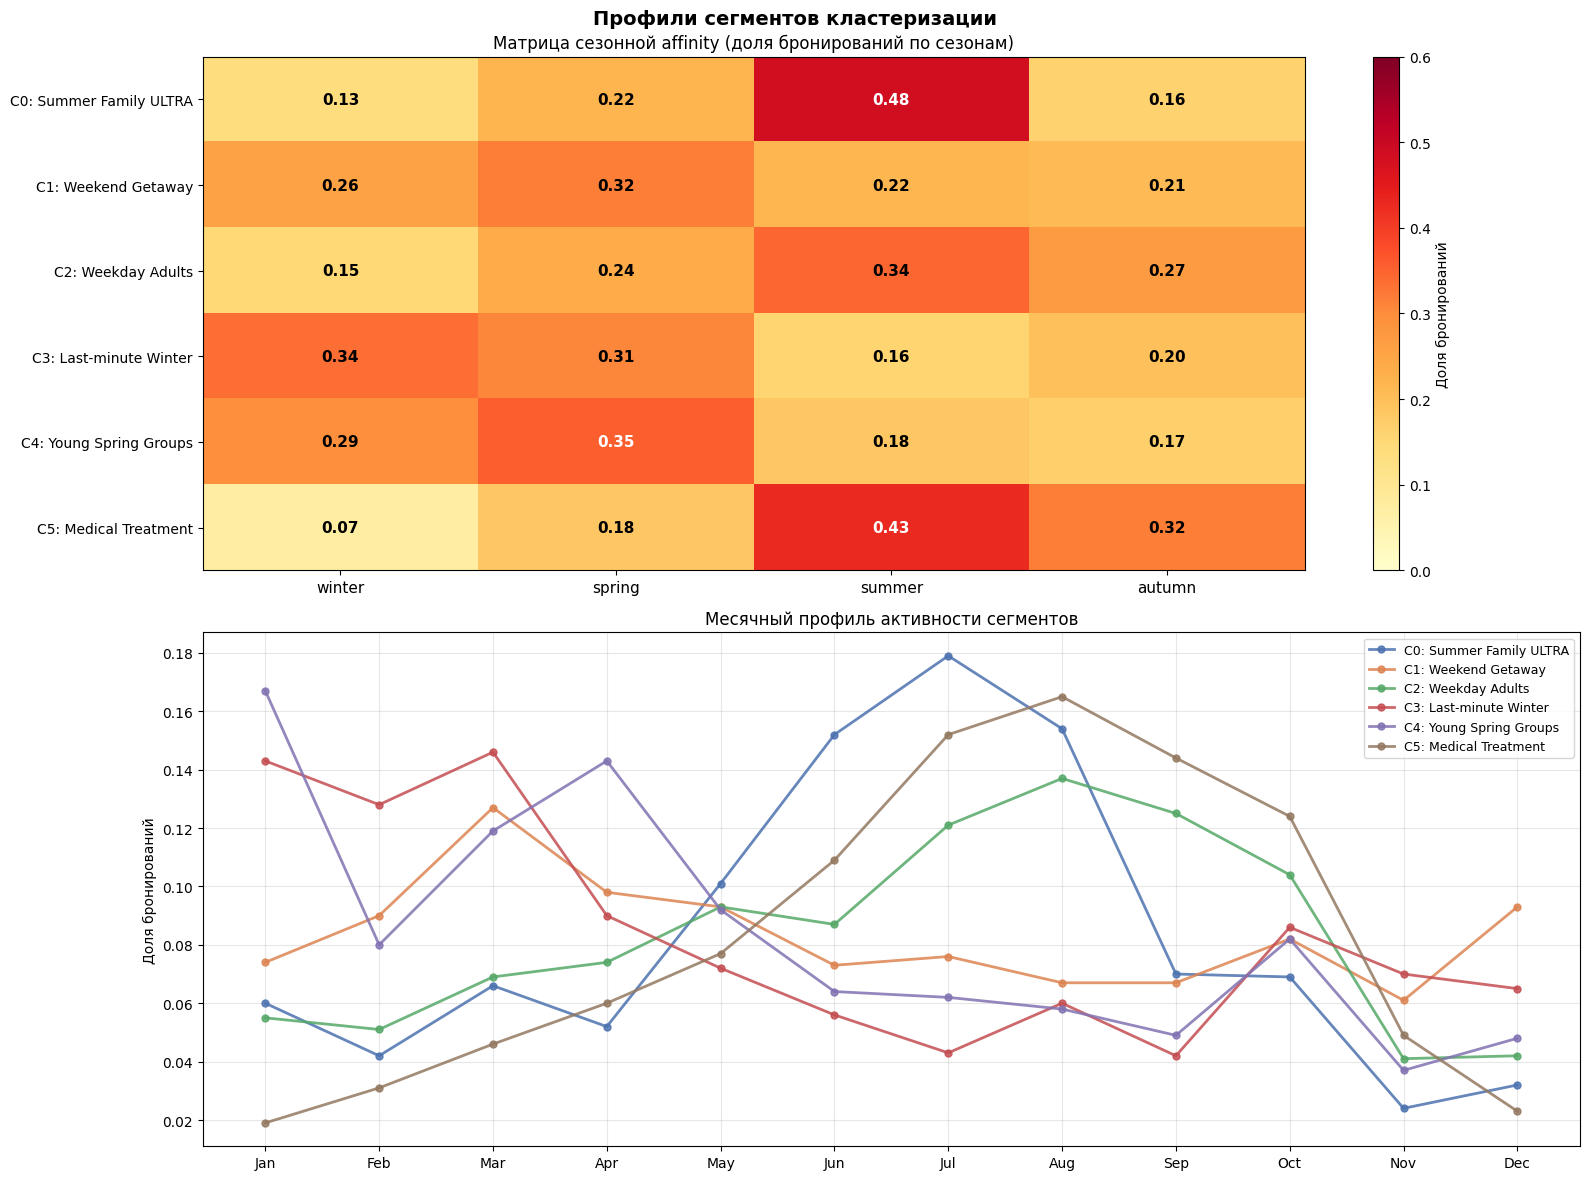

График сохранён: artifacts_recommender/segment_profiles.png


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Профили сегментов кластеризации', fontsize=14, fontweight='bold')

# ── График 1: Тепловая карта сезонной affinity ────────────────────────────────
ax1 = axes[0]
im = ax1.imshow(season_affinity.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.6)

ax1.set_xticks(range(len(season_affinity.columns)))
ax1.set_xticklabels(season_affinity.columns, fontsize=11)
ax1.set_yticks(range(len(season_affinity)))
ax1.set_yticklabels([f'C{i}: {SEGMENT_NAMES[i]}' for i in season_affinity.index], fontsize=10)
ax1.set_title('Матрица сезонной affinity (доля бронирований по сезонам)')

# Подписи значений на ячейках
for i in range(len(season_affinity)):
    for j in range(len(season_affinity.columns)):
        val = season_affinity.values[i, j]
        ax1.text(j, i, f'{val:.2f}', ha='center', va='center',
                 fontsize=11, fontweight='bold',
                 color='white' if val > 0.35 else 'black')

plt.colorbar(im, ax=ax1, label='Доля бронирований')

# ── График 2: Месячный профиль (линейный) ────────────────────────────────────
ax2 = axes[1]
months = list(segment_monthly.columns)
x = range(len(months))

for i, cluster_id in enumerate(segment_monthly.index):
    values = segment_monthly.loc[cluster_id].values
    ax2.plot(x, values, marker='o', linewidth=2, markersize=5,
             color=COLORS[i], label=f'C{cluster_id}: {SEGMENT_NAMES[cluster_id]}', alpha=0.85)

ax2.set_xticks(list(x))
ax2.set_xticklabels(months)
ax2.set_ylabel('Доля бронирований')
ax2.set_title('Месячный профиль активности сегментов')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: artifacts_recommender/segment_profiles.png')

## 7. Сохранение артефактов

In [8]:
# Сохраняем сводную таблицу метрик сегментов
df_seg_stats.to_parquet(OUT_DIR / 'segment_history.parquet')
print(f'Сохранено: segment_history.parquet ({len(df_seg_stats)} сегментов)')

# Сохраняем матрицу сезонной affinity
season_affinity.to_parquet(OUT_DIR / 'season_affinity.parquet')
print(f'Сохранено: season_affinity.parquet ({season_affinity.shape})')

# Сохраняем месячный профиль
segment_monthly.to_parquet(OUT_DIR / 'segment_monthly.parquet')
print(f'Сохранено: segment_monthly.parquet ({segment_monthly.shape})')

print('\n=== ИТОГОВЫЕ МЕТРИКИ СЕГМЕНТОВ ===')
print(df_seg_stats[['segment_name','total_bookings','pct_of_total','avg_nights']].to_string())
print('\nГотово! Следующий шаг → 06_segment_scoring.ipynb')

Сохранено: segment_history.parquet (6 сегментов)
Сохранено: season_affinity.parquet ((6, 4))
Сохранено: segment_monthly.parquet ((6, 12))

=== ИТОГОВЫЕ МЕТРИКИ СЕГМЕНТОВ ===
                   segment_name  total_bookings  pct_of_total  avg_nights
cluster_v4                                                               
0           Summer Family ULTRA           19473          20.5       6.487
1               Weekend Getaway           12251          12.9       4.037
2                Weekday Adults           25143          26.5       7.238
3            Last-minute Winter           18386          19.3       1.999
4           Young Spring Groups           11590          12.2       4.459
5             Medical Treatment            8194           8.6       9.716

Готово! Следующий шаг → 06_segment_scoring.ipynb
